<a href="https://colab.research.google.com/github/bayan2002/Chicago-Crime-Time-Series-Analysis/blob/main/Chicago_Crime_Analysis_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.tsa.api as tsa
import holidays
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams['figure.figsize'] = (12, 4)
sns.set_context("talk", font_scale=0.9)

#Load the data

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import zipfile
import os
import glob

zip_path = "/content/drive/MyDrive/AXSOSACADEMY/06-AdvancedML/Week21/Data/Chicago_Crime_2001-2022.zip"
extract_to = "chicago_crime_extracted"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)


all_files = glob.glob(os.path.join(extract_to, "Data/*.csv"))

# قراءة كل ملف ووضعه في قائمة، ثم دمجها جميعاً
df_list = [pd.read_csv(f) for f in all_files]
df = pd.concat(df_list, ignore_index=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


In [9]:

df.head()
df.info()
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df = df.dropna(subset=['Date'])

df = df.set_index('Date')
df = df.sort_index()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7713109 entries, 0 to 7713108
Data columns (total 12 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Date                  object 
 2   Primary Type          object 
 3   Description           object 
 4   Location Description  object 
 5   Arrest                bool   
 6   Domestic              bool   
 7   Beat                  int64  
 8   District              float64
 9   Ward                  float64
 10  Latitude              float64
 11  Longitude             float64
dtypes: bool(2), float64(4), int64(2), object(4)
memory usage: 603.2+ MB


/tmp/ipykernel_12198/3980509000.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [11]:
df.head()

,ID,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Latitude,Longitude
Date,,,,,,,,,,,
2001-01-01,3824165,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,1121,11.0,26.0,41.899291,-87.707551
2001-01-01,3214584,THEFT,FINANCIAL ID THEFT: OVER $300,STREET,False,False,2221,22.0,21.0,41.732563,-87.669923
2001-01-01,1651806,THEFT,FINANCIAL ID THEFT:$300 &UNDER,RESIDENCE,False,False,1932,19.0,NaN,41.938485,-87.656344
2001-01-01,11950657,OFFENSE INVOLVING CHILDREN,SEXUAL ASSAULT OF CHILD BY FAMILY MEMBER,RESIDENCE,True,True,825,8.0,16.0,NaN,NaN
2001-01-01,9754994,SEX OFFENSE,AGG CRIMINAL SEXUAL ABUSE,CHURCH/SYNAGOGUE/PLACE OF WORSHIP,False,False,1022,10.0,24.0,NaN,NaN


In [10]:
print(df.isna().sum())


ID                           0
Primary Type                 0
Description                  0
Location Description     10928
Arrest                       0
Domestic                     0
Beat                         0
District                    47
Ward                    614846
Latitude                 88685
Longitude                88685
dtype: int64


In [ ]:
daily_crimes = df.resample('D').size().to_frame('Total Crimes')


#2- (Crimes Across the Years)

/tmp/ipykernel_12198/4085526017.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Year', palette='dark')


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21],
 [Text(0, 0, '2001'),
  Text(1, 0, '2002'),
  Text(2, 0, '2003'),
  Text(3, 0, '2004'),
  Text(4, 0, '2005'),
  Text(5, 0, '2006'),
  Text(6, 0, '2007'),
  Text(7, 0, '2008'),
  Text(8, 0, '2009'),
  Text(9, 0, '2010'),
  Text(10, 0, '2011'),
  Text(11, 0, '2012'),
  Text(12, 0, '2013'),
  Text(13, 0, '2014'),
  Text(14, 0, '2015'),
  Text(15, 0, '2016'),
  Text(16, 0, '2017'),
  Text(17, 0, '2018'),
  Text(18, 0, '2019'),
  Text(19, 0, '2020'),
  Text(20, 0, '2021'),
  Text(21, 0, '2022')])

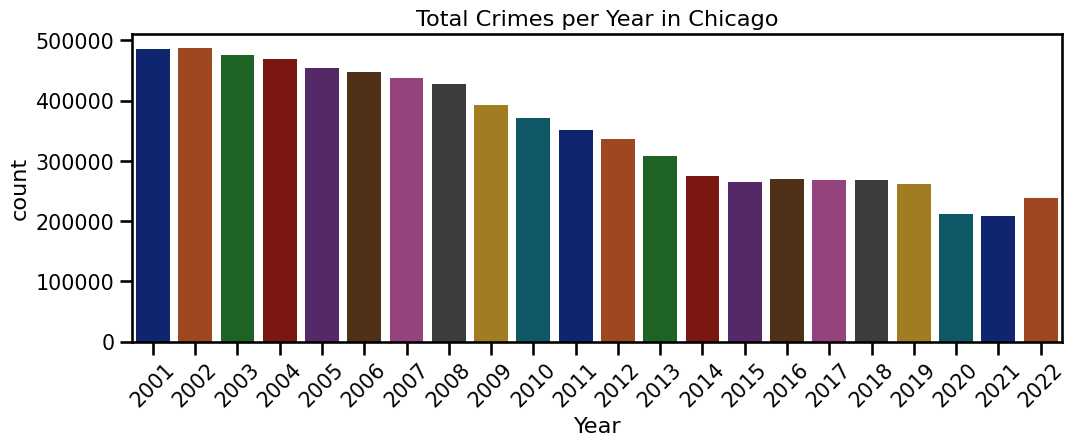

In [16]:
import matplotlib.pyplot as plt
df['Year'] = df.index.year
sns.countplot(data=df, x='Year', palette='dark')
plt.title('Total Crimes per Year in Chicago')
plt.xticks(rotation=45)

#Topic 2: Crimes Across the Years
##**Pattern:** There is a significant and consistent long-term decreasing trend in the total number of reported crimes in Chicago from 2001 to 2021
.
##**Observation:** The annual crime count dropped from nearly 500,000 cases in 2001 to its lowest levels in 2020 and 2021, followed by a slight increase in 2022

# 4- (Comparing Months)

/tmp/ipykernel_12198/33316628.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='MonthName', order=month_order, palette='viridis')


Text(0.5, 1.0, 'Comparison of Crimes by Month')

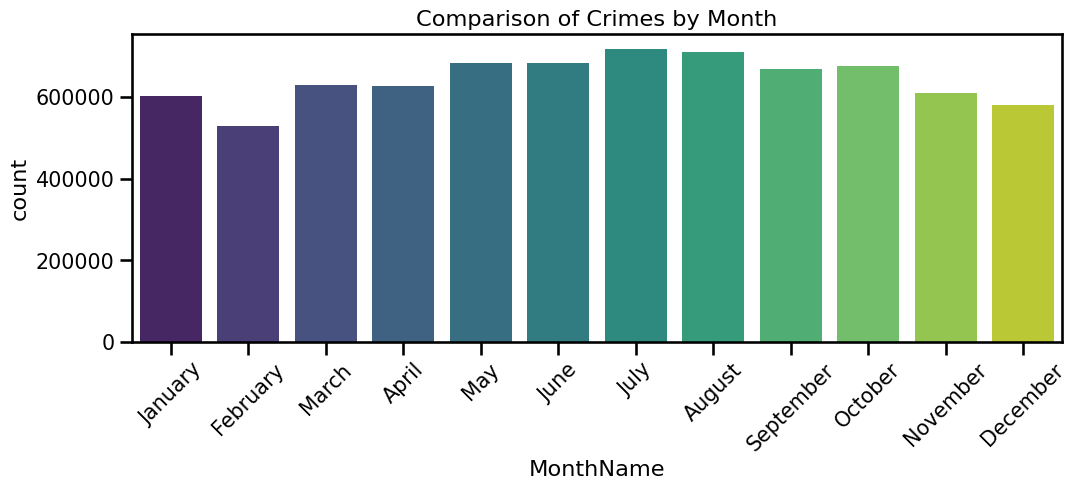

In [13]:

df['MonthName'] = df.index.month_name()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

sns.countplot(data=df, x='MonthName', order=month_order, palette='viridis')
plt.xticks(rotation=45)
plt.title('Comparison of Crimes by Month')

#Topic 4: Comparing Months
##**Pattern:** Crime rates follow a clear annual seasonal cycle, likely influenced by weather conditions

##**Observation:** The highest crime rates consistently occur during the summer months (July and August), while the lowest crime rates are recorded during the winter, with February being the month with the least crime


#6- (Seasonality)

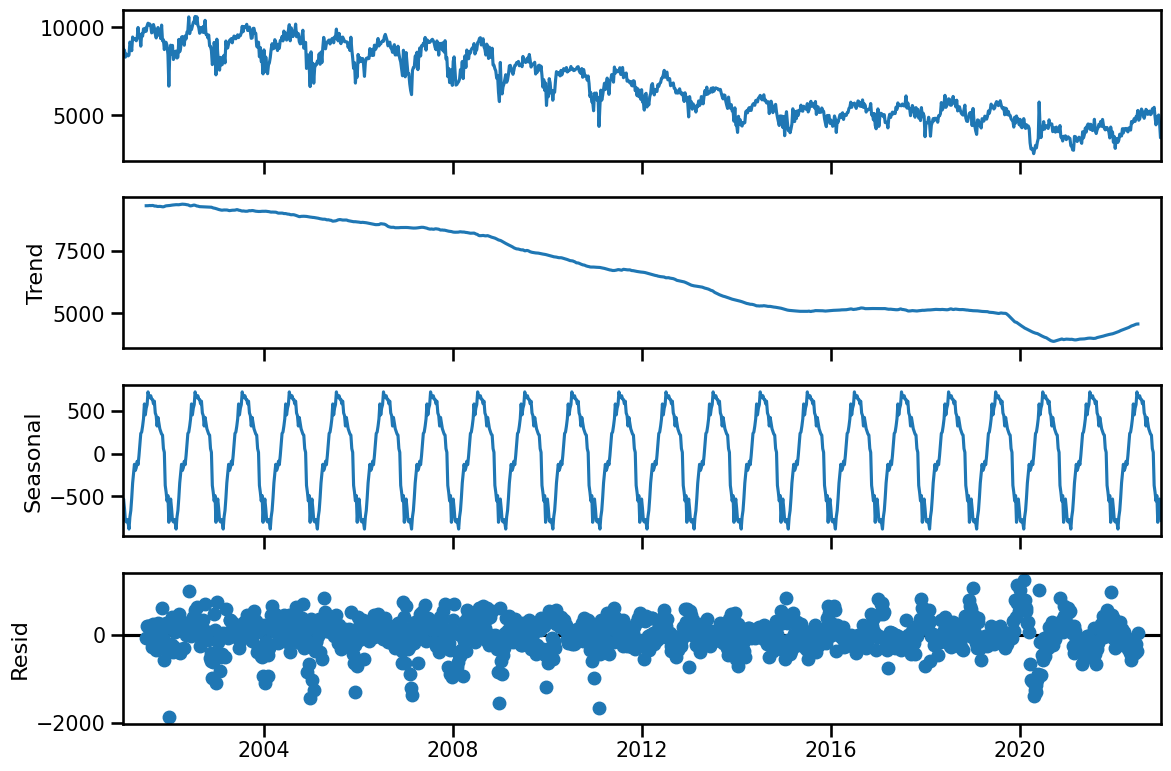

In [14]:
weekly_crimes = df.resample('W').size()

decomp = seasonal_decompose(weekly_crimes)
fig = decomp.plot()
fig.set_size_inches(12, 8)
fig.tight_layout()

#Topic 6: Seasonality (Decomposition)
##**Pattern:** The weekly crime data exhibits a regular repeating cycle that occurs every year

##**Cycle Length:** Each complete cycle lasts approximately one year (52 weeks)

##**Magnitude:** The seasonal component shows a fluctuation magnitude of roughly 1,500 crimes per week between the peak and the trough (ranging from approximately +700 to -800 crimes relative to the trend)

##**Insight:** The decomposition confirms that the overall downward trend remains present even after accounting for these regular seasonal fluctuations
